# Encoder Transformer — the reading half (BERT-style)

An **encoder** reads a whole piece of text at once and turns every word into a vector that knows its context. Every
word may look at every other word — **left and right**, earlier and later — because nothing is being written, only
understood. That makes encoders the tool for *understanding* jobs: is this review positive? Which words are names?
Which document matches this search? BERT, RoBERTa and DistilBERT are encoders.

How data flows through an encoder (we build the pieces in exactly this order):
```
 "[CLS] not bad and very fun"            ← raw text, with a [CLS] "summary seat" in front
      ↓  tokenizer                       ← words → ID numbers
 1. Embeddings                           ← ID numbers → meaning vectors
 2. + Positional Encoding                ← stamp each vector with its seat number
      ↓
 ┌─ Encoder block (repeated N times) ─────────────────────┐
 │ 3–5. Multi-Head Self-Attention + padding mask          │  ← every word looks at every word, both ways
 │ 6.   Add & Norm                                        │  ← keep the original + steady the numbers
 │ 7.   Feed-Forward Network                              │  ← each word "thinks" on its own
 │ 6.   Add & Norm                                        │
 └────────────────────────────────────────────────────────┘
      ↓
 9.  Final LayerNorm
 10. [CLS] vector → Linear layer + Softmax   ← one prediction for the whole text
      ↓
 "positive"
```

**The full cycle:** Part 1 builds every piece by hand. Part 2 snaps them into a tiny BERT and **trains it** to read
mini movie reviews — including the word *"not"*, which only works if the model notices word order.

**Companion notebooks:** `decoderTransformer.ipynb` (the writing half, GPT-style), `transformer.ipynb` (both halves
together, for translation) and `sentimentTransformer.ipynb` (a real pre-trained BERT on IMDB movie reviews).

In [1]:
# ==========================================
# 0. SETUP
# ==========================================
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)   # Fix the dice rolls so every run prints the same numbers
np.set_printoptions(precision=3, suppress=True)   # Print numbers to 3 decimals, no scientific notation
torch.set_printoptions(precision=3, sci_mode=False)

## Part 1 — The Building Blocks

### 1. Embeddings — turning words into numbers

A neural network can only do maths on numbers, so first every word (token) is swapped for an ID from a fixed
**vocabulary** (the model's dictionary), and then each ID is swapped for a **vector** — a list of numbers that
describes the word, like GPS coordinates for its meaning.

`nn.Embedding` is simply a big lookup table: one row per word in the vocabulary. The rows start out random and are
**learned** during training, so words used in similar ways (*"cat"*, *"dog"*) drift close together.

In [2]:
# ==========================================
# 1. EMBEDDINGS (word ID → meaning vector)
# ==========================================
vocabulary_size = 10000      # How many different tokens the model knows
embedding_dimension = 128    # How many numbers describe each token (GPT-2 uses 768)

# Step A: The lookup table - 10,000 rows, each a 128-number vector (random until trained)
embedding_layer = nn.Embedding(vocabulary_size, embedding_dimension)

print("=== THE MODEL'S INTERNAL DICTIONARY MATRIX ===")
print("Shape of full weight matrix:", embedding_layer.weight.shape)
print(embedding_layer.weight.data)
print("=" * 50 + "\n")

# Step B: A batch of 2 sentences, each already turned into 4 token IDs by a tokenizer
# Shape: (batch_size=2, sequence_length=4)
input_tokens = torch.tensor([
    [12, 45, 92, 17],
    [31, 11, 76, 12]      # Note: token 12 appears in both sentences
])

# Step C: Look up the vector for every token
embedded_sentence = embedding_layer(input_tokens)

print("=== FORWARD PASS TRACE ===")
print("1. Original Input Tensor:")
print(f"   Shape: {input_tokens.shape} -> (Batch Size, Sequence Length)")
print(f"   Values: {input_tokens.tolist()}\n")

print("2. Embedded Output Matrix:")
print(f"   Shape: {embedded_sentence.shape} -> (Batch Size, Sequence Length, Embedding Dim)")
print("   Values:")
print(embedded_sentence.data)
print("=" * 26)

# Step D: The same token always gets the same vector - no matter which sentence or position it's in
print("Token 12 gets the same vector in both sentences:", torch.equal(embedded_sentence[0, 0], embedded_sentence[1, 3]))

=== THE MODEL'S INTERNAL DICTIONARY MATRIX ===
Shape of full weight matrix: torch.Size([10000, 128])
tensor([[ 1.927,  1.487,  0.901,  ...,  0.340,  0.720,  0.411],
        [ 1.931,  1.012, -1.436,  ...,  0.566,  0.506,  0.222],
        [-0.685,  0.564, -1.507,  ...,  0.854, -0.490, -0.359],
        ...,
        [-0.058, -0.052, -0.871,  ..., -0.335, -0.043,  1.270],
        [ 0.852,  0.321,  0.985,  ..., -0.556,  0.215,  1.271],
        [-2.187, -0.133,  0.997,  ..., -0.851,  0.301, -0.808]])

=== FORWARD PASS TRACE ===
1. Original Input Tensor:
   Shape: torch.Size([2, 4]) -> (Batch Size, Sequence Length)
   Values: [[12, 45, 92, 17], [31, 11, 76, 12]]

2. Embedded Output Matrix:
   Shape: torch.Size([2, 4, 128]) -> (Batch Size, Sequence Length, Embedding Dim)
   Values:
tensor([[[-0.850, -0.699, -0.205,  ...,  0.382, -1.653, -0.381],
         [-1.039, -0.143,  1.130,  ..., -1.784, -1.239,  0.937],
         [ 0.132, -1.005,  0.125,  ..., -0.614, -1.303,  0.495],
         [-1.434, -0.

That last line is a problem in disguise: *"dog bites man"* and *"man bites dog"* give the model **exactly the same
three vectors**, just shuffled. Nothing yet says *where* each word sits. That's the job of the next piece.

### 2. Positional Encoding — giving every word a seat number

Self-attention (next section) compares every word with every other word, but the comparison **ignores order** —
to attention, a sentence is a bag of words. So before attention runs, we **add** a unique "position fingerprint"
to each word's vector: position 0 gets one pattern, position 1 another, and so on.

The original Transformer paper built these fingerprints out of sine and cosine waves of different speeds — like a
clock with many hands: the fast hands tell neighbouring positions apart, the slow hands tell far-apart positions
apart. Every position ends up with a unique combination.

=== 1. POSITIONAL ENCODING MATRIX ===
Positional encoding shape: torch.Size([1, 4, 128])
tensor([[ 0.000,  1.000,  0.000,  1.000,  0.000,  1.000,  0.000,  1.000],
        [ 0.841,  0.540,  0.762,  0.648,  0.682,  0.732,  0.605,  0.796],
        [ 0.909, -0.416,  0.987, -0.160,  0.997,  0.071,  0.963,  0.269],
        [ 0.141, -0.990,  0.517, -0.856,  0.778, -0.628,  0.930, -0.368]])

=== 2. FINAL INTEGRATED TRANSFORMER INPUT ===
Shape: Embeddings + positions: torch.Size([2, 4, 128])
tensor([[[-0.850,  0.301, -0.205,  ...,  1.382, -1.653,  0.619],
         [-0.197,  0.397,  1.892,  ..., -0.784, -1.239,  1.937],
         [ 1.041, -1.421,  1.112,  ...,  0.386, -1.303,  1.495],
         [-1.292, -1.866,  0.527,  ...,  0.970,  1.272,  2.085]],

        [[ 0.308,  0.872,  0.037,  ...,  0.860,  0.942,  0.988],
         [ 1.112, -0.642, -0.272,  ...,  1.220,  0.325,  2.319],
         [ 0.622, -1.470, -0.610,  ...,  1.239,  0.740,  2.561],
         [-0.709, -1.689,  0.312,  ...,  1.382, -1.652,

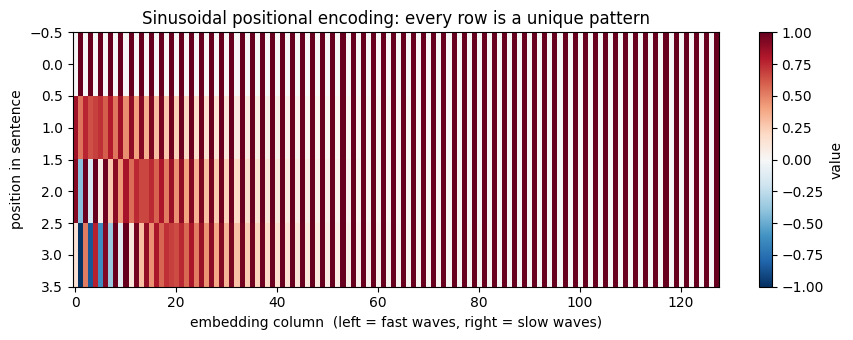

In [3]:
# ==========================================
# 2. POSITIONAL ENCODING (sine/cosine "seat numbers")
# ==========================================
sequence_length = embedded_sentence.shape[1]   # 4 words per sentence

def positional_encoding(sequence_length, dimension):
    # 1. Positions as a column: (seq_len, 1) -> [[0], [1], [2], [3]]
    position = torch.arange(0, sequence_length, dtype=torch.float32).unsqueeze(1)

    # 2. div_term sets the speed of each wave (fast on the left columns, slow on the right)
    div_term = torch.exp(torch.arange(0, dimension, 2) * (-torch.log(torch.tensor(10000.0)) / dimension))

    # 3. A blank matrix to fill in: (sequence_length, dimension)
    pe = torch.zeros(sequence_length, dimension)

    # 4. Even columns (0, 2, 4...) get sine waves, odd columns (1, 3, 5...) get cosine waves
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    # 5. Add a batch dimension so it lines up with embedded_sentence: (4, 128) → (1, 4, 128)
    return pe.unsqueeze(0)

pe = positional_encoding(sequence_length, embedding_dimension)

# Add the position stamps to the word vectors
final_transformer_input = embedded_sentence + pe

print("=== 1. POSITIONAL ENCODING MATRIX ===")
print("Positional encoding shape:", pe.shape)   # (1, positions, numbers per position)
print(pe[0, :, :8])   # Shows the first 8 columns

print("\n=== 2. FINAL INTEGRATED TRANSFORMER INPUT ===")
print("Shape: Embeddings + positions:", final_transformer_input.shape)
print(final_transformer_input.data)

print("Token 12 still identical in both sentences?", torch.equal(final_transformer_input[0, 0], final_transformer_input[1, 3]))   # Seat 0 vs seat 3

# Picture it - each row is one position's fingerprint
plt.figure(figsize=(9, 3.5))
plt.imshow(pe[0], cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")   # Blue = -1, white = 0, red = +1
plt.colorbar(label="value")
plt.xlabel("embedding column  (left = fast waves, right = slow waves)")
plt.ylabel("position in sentence")
plt.title("Sinusoidal positional encoding: every row is a unique pattern")
plt.tight_layout()
plt.show()

Read the picture left to right: the first columns flip colour every row or two (fast hands), the right-hand columns
barely change over 4 positions (slow hands) — which is why they show up as plain stripes: sine columns sit near 0
(white), cosine columns near 1 (red). No two rows are identical.

**Modern models don't all use this exact method.** GPT-2 and `tinyGpt.ipynb` use **learned** position embeddings
(just another `nn.Embedding`, indexed by position); Llama and most recent LLMs use **RoPE** (rotary embeddings, which
*rotate* the query and key vectors by an angle that depends on position). The goal is always the same: tell
attention where each word is.

### 3. Self-Attention — how words look at each other

This is the heart of the Transformer. Picture a **library visit**: you walk in with a **query** (*"I need something
about sleepy animals"*). Every book has a **key** (the label on its spine) and a **value** (what's actually inside).
You compare your query against every key, score how well each matches, and walk out with a **blend** of the books'
contents — mostly from the best matches, a little from the rest.

In a sentence, **every word does this at once**: each word is a reader (query) *and* a book (key + value) for all
the others. It takes four steps — **score, scale, soften, blend**:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

| Step | Maths | Plain English |
|---|---|---|
| 1. Score | $QK^\top$ | Dot product: how well does each query match each key? |
| 2. Scale | $\div \sqrt{d_k}$ | Shrink the scores so softmax doesn't become winner-takes-all ($d_k$ = numbers per key) |
| 3. Soften | softmax | Turn each row of scores into percentages that add up to 1 (the **attention weights**) |
| 4. Blend | $\times V$ | Each word's output = weighted average of all the values |

Let's do it by hand with 2 tiny words, each described by 2 numbers.

In [4]:
# ==========================================
# 3A. SELF-ATTENTION BY HAND (NumPy, 2 words × 2 numbers)
# ==========================================
Q = np.array([[1.0, 0.0],     # Word 1's question: "what am I looking for?"
              [0.0, 1.0]])    # Word 2's question
K = np.array([[1.0, 0.0],     # Word 1's label: "what do I contain?"
              [0.5, 1.0]])    # Word 2's label
V = np.array([[2.0, 1.0],     # Word 1's content: "what I share if picked"
              [1.0, 3.0]])    # Word 2's content

# Step 1 - SCORE: every query dotted with every key. Row = the reader, column = the book
scores = Q @ K.T
print("1. Raw scores (row i = how much word i matches each word):\n", scores)

# Step 2 - SCALE: divide by √d_k so bigger vectors don't give giant scores
d_k = K.shape[1]
scaled = scores / np.sqrt(d_k)
print("\n2. Scaled scores (÷ √2):\n", scaled)

# Step 3 - SOFTEN: softmax each row so it becomes percentages adding to 1
def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))   # Subtract the max first - avoids overflow, same answer
    return e / e.sum(axis=-1, keepdims=True)

weights = softmax(scaled)
print("\n3. Attention weights (each row sums to 1):\n", weights)
print("   Row sums:", weights.sum(axis=1))

# Step 4 - BLEND: each word's new vector = weighted mix of every word's value
output = weights @ V
print("\n4. Output (each word now carries context from the other):\n", output)

1. Raw scores (row i = how much word i matches each word):
 [[1.  0.5]
 [0.  1. ]]

2. Scaled scores (÷ √2):
 [[0.707 0.354]
 [0.    0.707]]

3. Attention weights (each row sums to 1):
 [[0.587 0.413]
 [0.33  0.67 ]]
   Row sums: [1. 1.]

4. Output (each word now carries context from the other):
 [[1.587 1.825]
 [1.33  2.34 ]]


Read row 1 of the weights: word 1 spends **~59%** of its attention on itself and **~41%** on word 2, so its output
`[1.587, 1.825]` is mostly word 1's value `[2, 1]` with a good dose of word 2's value `[1, 3]` mixed in. The word
went in "alone" and came out **aware of its neighbour** — that's what "contextual representation" means.

**Where do Q, K and V come from?** Above we typed them in. In a real model they are all made **from the same input
vectors `x`**, each through its own learned linear layer (a learned "translation"). Same word, three roles. That's
why it's called *self*-attention: the sentence attends to itself.

In [5]:
# ==========================================
# 3B. SELF-ATTENTION IN PYTORCH (Q, K, V learned from the same input)
# ==========================================
# 1. Three linear layers that turn each word into its query, key and value
# In a real transformer, these weights are learned during training
W_q = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_k = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_v = nn.Linear(embedding_dimension, embedding_dimension, bias=False)

# Project our input into Queries, Keys, and Values
Q = W_q(final_transformer_input)  # Shape: (2, 4, 128)
K = W_k(final_transformer_input)  # Shape: (2, 4, 128)
V = W_v(final_transformer_input)  # Shape: (2, 4, 128)

print("=== 1. MATRICES GENERATED ===")
print("Query (Q) Shape:", Q.shape)
print("Key (K) Shape:", K.shape)
print("Value (V) Shape:", V.shape, "\n")

# 2. Step-by-step attention maths
# Step A: Raw scores - Q times K turned on its side (transpose the last two dimensions of K)
scores = torch.matmul(Q, K.transpose(-2, -1))  # Shape: (2, 4, 4)
print("A. Raw scores (row i = how much word i matches each word):\n", scores)

# Step B: Scale the scores
d_k = K.size(-1)
scaled_scores = scores / math.sqrt(d_k)
print(f"\nB. Scaled scores (÷ √{d_k}):\n", scaled_scores)

# Step C: Softmax turns each row into attention weights (percentages)
attention_weights = torch.softmax(scaled_scores, dim=-1)
print("\n=== C. ATTENTION WEIGHTS (PROBABILITIES) ===")
print("Shape:", attention_weights.shape, "-> (Batch, Word_Q, Word_K)")
print("Row sums:", attention_weights.sum(dim=-1))
print(attention_weights.data, "\n")

# Step D: Blend - multiply the weights by the values
attention_output = torch.matmul(attention_weights, V)  # Shape: (2, 4, 128)

print("=== D. FINAL SELF-ATTENTION OUTPUT ===")
print("Shape:", attention_output.shape, "-> (Batch, Seq_Len, Embedding_Dim)")
print(attention_output.data)

=== 1. MATRICES GENERATED ===
Query (Q) Shape: torch.Size([2, 4, 128])
Key (K) Shape: torch.Size([2, 4, 128])
Value (V) Shape: torch.Size([2, 4, 128]) 

A. Raw scores (row i = how much word i matches each word):
 tensor([[[  8.397,   4.040,   6.175,   3.227],
         [  6.192,  -6.658,  16.473,   5.910],
         [ -1.758,  -1.248,   3.295,   3.864],
         [ 13.140,   0.412,   9.165,   9.276]],

        [[ -2.371,  -1.599, -11.330,  -2.225],
         [  2.700,   0.167,   3.464,   5.901],
         [  6.376,  -1.249,  -9.841,   4.960],
         [  6.123,   9.368,   6.422,   9.819]]], grad_fn=<UnsafeViewBackward0>)

B. Scaled scores (÷ √128):
 tensor([[[ 0.742,  0.357,  0.546,  0.285],
         [ 0.547, -0.588,  1.456,  0.522],
         [-0.155, -0.110,  0.291,  0.341],
         [ 1.161,  0.036,  0.810,  0.820]],

        [[-0.210, -0.141, -1.001, -0.197],
         [ 0.239,  0.015,  0.306,  0.522],
         [ 0.564, -0.110, -0.870,  0.438],
         [ 0.541,  0.828,  0.568,  0.868]]],

The weights are spread out fairly evenly because the linear layers are random — nothing has been learned yet. After
training, a row like *"it"* in *"the animal didn't cross the street because **it** was tired"* concentrates its
weight on *"animal"*.

The output has the **same shape as the input**: 4 words × 128 numbers in, 4 words × 128 numbers out. That's what
lets us stack attention layers on top of each other.

### 4. The Padding Mask — the encoder's only mask

Sometimes a word must **not** be looked at. The trick is always the same: set the forbidden scores to **−∞** before
softmax. Since $e^{-\infty} = 0$, those words get **exactly 0%** attention, and the remaining percentages still add
up to 1.

Sentences in a batch have different lengths, so short ones get padded with a dummy `<pad>` token to line them up
(like filling empty seats in a row). Nobody should pay attention to padding — that's the **padding mask**.

An encoder needs **no other mask**. It isn't writing anything, so there's no "future" to hide: word 2 is allowed to
look at word 4. (The *causal* mask, which hides later words, belongs to text generators — see
`decoderTransformer.ipynb`.)

=== 1. SCORES AFTER PADDING MASK ===
tensor([[ 0.742,  0.357,   -inf,   -inf],
        [ 0.547, -0.588,   -inf,   -inf],
        [-0.155, -0.110,   -inf,   -inf],
        [ 1.161,  0.036,   -inf,   -inf]]) 

=== 2. FINAL ATTENTION WEIGHTS (PROBABILITIES) ===
tensor([[0.595, 0.405, 0.000, 0.000],
        [0.757, 0.243, 0.000, 0.000],
        [0.489, 0.511, 0.000, 0.000],
        [0.755, 0.245, 0.000, 0.000]])
Row sums: tensor([1., 1., 1., 1.])


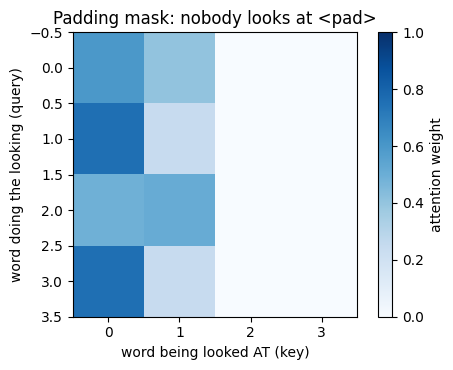

In [6]:
# ==========================================
# 4. PADDING MASK
# ==========================================
scaled_4x4 = scaled_scores[0].detach()   # Sentence 1's 4×4 scaled scores from section 3B

# Step A: Pretend the last 2 of our 4 tokens are <pad> filler. True = a real word
is_real = torch.tensor([True, True, False, False])

# Step B: Hide the <pad> COLUMNS - nobody may look AT a pad token
masked_scores = scaled_4x4.masked_fill(~is_real, float("-inf"))   # The (4,) mask is copied across every row
print("=== 1. SCORES AFTER PADDING MASK ===")
print(masked_scores.data, "\n")

# Step C: Softmax - the pad columns become exactly 0, and each row still adds up to 1
pad_weights = torch.softmax(masked_scores, dim=-1)
print("=== 2. FINAL ATTENTION WEIGHTS (PROBABILITIES) ===")
print(pad_weights.data)
print("Row sums:", pad_weights.sum(dim=-1))

# Step D: Picture it
plt.figure(figsize=(5, 3.8))
plt.imshow(pad_weights, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xlabel("word being looked AT (key)")
plt.ylabel("word doing the looking (query)")
plt.title("Padding mask: nobody looks at <pad>")
plt.tight_layout()
plt.show()

The last two columns are 0 for every word, so the filler adds nothing to anyone's output — while the real words still
see each other in **both** directions (row 1 looks at word 2, row 2 looks at word 1).

The `<pad>` rows themselves still get an output, but nothing downstream uses it: the classifier at the end reads
only the `[CLS]` seat.

In PyTorch's built-in layers you don't build this by hand: you pass `key_padding_mask=` (or
`src_key_padding_mask=`). **Careful:** there, `True` means *"ignore this position"* — the opposite of our `is_real`.
From section 5 on we use PyTorch's convention.

### 5. Multi-Head Attention — several readers at once

One attention pattern gives each word **one way** of looking at the sentence. But language has many relationships at
the same time: which noun does *"it"* refer to, which adjective describes which noun, which verb goes with which
subject…

**Multi-head attention** runs several attention "heads" side by side, like a team of readers each hunting for a
different kind of clue. The 128 numbers per word are **split** between the heads (8 heads × 16 numbers each), every
head does its own score–scale–soften–blend, and the results are glued back together and mixed by one final linear
layer. Splitting (rather than copying) means 8 heads cost about the same as 1 big head.

In [7]:
# ==========================================
# 5. MULTI-HEAD ATTENTION
# ==========================================
num_heads = 8
batch_size = final_transformer_input.shape[0]   # 2 sentences
d_k = embedding_dimension // num_heads          # Dimension per head = 16 (128 / 8)
print("Numbers each head works with:", d_k)

# 1. Linear projections for the full 128 numbers (the heads get split out afterwards)
W_q = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_k = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
W_v = nn.Linear(embedding_dimension, embedding_dimension, bias=False)
out_project = nn.Linear(embedding_dimension, embedding_dimension)   # Mixes the heads' findings back together

# 2. Project to get Q, K, V
Q = W_q(final_transformer_input)   # (2, 4, 128)
K = W_k(final_transformer_input)   # (2, 4, 128)
V = W_v(final_transformer_input)   # (2, 4, 128)

# 3. THE SPLIT STEP: reshape and swap axes so each head gets its own slice
# From (2, 4, 128) -> view (2, 4, 8, 16) -> transpose (2, 8, 4, 16) = (Batch, Heads, Seq_Len, d_k)
Q = Q.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)
K = K.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)
V = V.view(batch_size, sequence_length, num_heads, d_k).transpose(1, 2)

print("=== 1. HEAD SPLIT CONFIGURATION ===")
print("Shape of Q per head:", Q.shape, "-> (Batch, Heads, Seq_Len, Dim_Per_Head)\n")

# 4. Standard attention maths for all 8 heads at once - plus the padding mask
# Pretend sentence 2's last word is <pad> filler. True = "ignore this word" (PyTorch's convention)
padding_mask = torch.tensor([[False, False, False, False],
                             [False, False, False, True]])
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)              # (2, 8, 4, 4)
scores = scores.masked_fill(padding_mask[:, None, None, :], float("-inf"))   # Mask reshaped to (2, 1, 1, 4): same rule for every head and every row
attention_weights = torch.softmax(scores, dim=-1)                           # (2, 8, 4, 4): one 4×4 pattern per head
head_outputs = torch.matmul(attention_weights, V)                           # (2, 8, 4, 16)
print("Most attention ANY head pays to sentence 2's <pad>:", attention_weights[1, :, :, 3].max().item(), "\n")

# 5. THE MERGE STEP: glue the heads back together
# Swap back to (Batch, Seq_Len, Heads, d_k) -> (2, 4, 8, 16)
# Then flatten the last two dimensions back into d_model -> (2, 4, 128)
merged_heads = head_outputs.transpose(1, 2).contiguous().view(batch_size, sequence_length, embedding_dimension)

print("=== 2. MERGED HEADS COMPOSITE ===")
print("Shape after merging heads:", merged_heads.shape, "-> (Batch, Seq_Len, d_model)\n")

# 6. Final linear layer mixes what the 8 heads found
final_attention_output = out_project(merged_heads)
print("=== 3. FINAL LAYER TRANSFORMED OUTPUT ===")
print("Output Shape:", final_attention_output.shape)
print("Attention weights:", attention_weights.shape)

Numbers each head works with: 16
=== 1. HEAD SPLIT CONFIGURATION ===
Shape of Q per head: torch.Size([2, 8, 4, 16]) -> (Batch, Heads, Seq_Len, Dim_Per_Head)

Most attention ANY head pays to sentence 2's <pad>: 0.0 

=== 2. MERGED HEADS COMPOSITE ===
Shape after merging heads: torch.Size([2, 4, 128]) -> (Batch, Seq_Len, d_model)

=== 3. FINAL LAYER TRANSFORMED OUTPUT ===
Output Shape: torch.Size([2, 4, 128])
Attention weights: torch.Size([2, 8, 4, 4])


The weights shape shows the point: **8 separate 4×4 attention patterns per sentence**, one per head. The parameter
count is $3 \times 128 \times 128 + (128 \times 128 + 128) = 65{,}664$ — the Q, K, V and output projections. The
number of heads does **not** change it.

The mask works the same with many heads: one `(batch, words)` row of True/False is stretched across every head and
every row, so sentence 2's `<pad>` gets exactly 0 attention from all 8 heads.

### 6. Add & Norm — residual connections and layer normalization

Every sub-layer (attention, feed-forward) is wrapped in two helpers:

- **Add (residual connection)**: output = input **+** sub-layer(input). The sub-layer only has to learn a *correction*
  to what's already there, not rebuild the word from scratch. It's also a highway for gradients (the learning
  signal) to flow straight back through a deep stack of layers — without it, 12, 24 or 96 layers wouldn't train.
- **Norm (LayerNorm)**: rescales each word's numbers to average 0 and spread 1, so values can't slowly blow up or
  shrink as they pass through layer after layer. Like re-tuning an instrument between songs.

In [8]:
# ==========================================
# 6. ADD & NORM
# ==========================================
# LayerNorm used after attention
norm1 = nn.LayerNorm(embedding_dimension)

# 1. "Add" the original input to the attention output
x_residual_1 = final_transformer_input + final_attention_output
# 2. "Norm" the combined result
x_norm_1 = norm1(x_residual_1)

print(f"Before norm → average {x_residual_1.mean():.2f}, spread {x_residual_1.std():.2f}")
print(f"After norm  → average {x_norm_1.mean():.2f}, spread {x_norm_1.std():.2f}")

print("\n=== POST ADD & NORM ===")
print("Shape:", x_norm_1.shape)
print("Mean value per word (should be close to 0):")
print(torch.round(x_norm_1.mean(dim=-1), decimals=4).data)

Before norm → average 0.45, spread 1.12
After norm  → average 0.00, spread 1.00

=== POST ADD & NORM ===
Shape: torch.Size([2, 4, 128])
Mean value per word (should be close to 0):
tensor([[-0., 0., 0., 0.],
        [-0., -0., 0., -0.]])


**Post-norm vs pre-norm.** The original paper (and the code above) normalizes *after* adding:
`LayerNorm(x + sublayer(x))`. Almost every modern model (GPT-2 onward, `tinyGpt.ipynb`) normalizes *before* the
sub-layer instead: `x + sublayer(LayerNorm(x))` — it trains more stably when stacking many layers. In PyTorch's
built-in layers this is the `norm_first=True` switch.

### 7. Position-wise Feed-Forward Network — each word thinks on its own

Attention is where words **talk to each other**. The feed-forward network (FFN) is where each word **thinks by itself**
about what it just heard. It's a small two-layer network applied to every word **separately** (that's what
"position-wise" means — same network, each position on its own, no mixing between words).

It widens each word's vector (128 → 512, the usual 4×), applies a non-linearity (GELU here; the original paper used
ReLU, and Llama-style models use SwiGLU), then shrinks it back to 128 so the next layer gets the same shape. Then
comes Add & Norm again, just like after attention.

In [9]:
# ==========================================
# 7. POSITION-WISE FEED-FORWARD NETWORK
# ==========================================
# 1. Build the layers
norm2 = nn.LayerNorm(embedding_dimension)          # LayerNorm for the second Add & Norm
d_ff = embedding_dimension * 4                     # 512 (128 × 4): the widened size
ffn_layer1 = nn.Linear(embedding_dimension, d_ff)
ffn_activation = nn.GELU()                         # Non-linearity - lets it learn more than straight-line patterns
ffn_layer2 = nn.Linear(d_ff, embedding_dimension)

# Step B1: Widen 128 → 512
ffn_out = ffn_layer1(x_norm_1)
# Step B2: Apply the non-linearity
ffn_out = ffn_activation(ffn_out)
# Step B3: Shrink back 512 → 128
ffn_processed = ffn_layer2(ffn_out)

print("=== POST FFN PROCESSING ===")
print("Shape:", ffn_processed.shape, "-> (Preserves original layout)\n")

# Proof it's position-wise: word 3 run alone gives the same answer as word 3 inside the sentence
alone = ffn_layer2(ffn_activation(ffn_layer1(x_norm_1[:, 3:4, :])))
print("Word 3 alone == word 3 in the sentence:", torch.allclose(alone, ffn_processed[:, 3:4, :], atol=1e-6))

# Who holds the weights?
ffn_params  = sum(p.numel() for layer in (ffn_layer1, ffn_layer2) for p in layer.parameters())
attn_params = sum(p.numel() for layer in (W_q, W_k, W_v, out_project) for p in layer.parameters())
print(f"Feed-forward parameters: {ffn_params:,}")        # 131,712
print(f"Attention parameters   : {attn_params:,}")       # 65,664
print(f"Share held by the FFN  : {ffn_params / (ffn_params + attn_params):.0%}")   # 67%

# Step C: Second Add & Norm (residual connection around the FFN)
x_residual_2 = x_norm_1 + ffn_processed       # "Add" the pre-FFN vector to the post-FFN vector
final_block_output = norm2(x_residual_2)      # "Norm" the result

print("\n=== FINAL TRANSFORMER BLOCK OUTPUT ===")
print("Shape:", final_block_output.shape)

=== POST FFN PROCESSING ===
Shape: torch.Size([2, 4, 128]) -> (Preserves original layout)

Word 3 alone == word 3 in the sentence: True
Feed-forward parameters: 131,712
Attention parameters   : 65,664
Share held by the FFN  : 67%

=== FINAL TRANSFORMER BLOCK OUTPUT ===
Shape: torch.Size([2, 4, 128])


The humble FFN holds **about two thirds** of each layer's weights. Attention decides *where information flows*; the
feed-forward layers do much of the *storing and transforming* — a lot of what a large language model "knows" is
thought to live in them.

### 8. Putting It Together — one Encoder block from scratch

Now we snap sections 5–7 together into the unit that gets stacked 12, 24… times in real encoders (BERT-base has 12),
using the **pre-norm** layout from the note after section 6:

```
x ─┬─> LayerNorm ─> Multi-Head Attention ─> (+) ─┬─> LayerNorm ─> Feed-Forward ─> (+) ─> out
   └─────────────────────────────────────────┘   └─────────────────────────────────┘
              residual connection                       residual connection
```

Two checks: the padding mask must really protect the real words, and our block must have **exactly the same number
of weights** as PyTorch's `nn.TransformerEncoderLayer`.

In [10]:
# ==========================================
# 8. ONE ENCODER BLOCK FROM SCRATCH
# ==========================================
class EncoderBlock(nn.Module):
    def __init__(self, d_model=128, num_heads=8, dim_feedforward=512, dropout=0.1):
        super().__init__()
        # 1. Multi-head self-attention (section 5) - PyTorch's built-in version of what we wrote by hand
        self.attention = nn.MultiheadAttention(d_model, num_heads, dropout=dropout, batch_first=True)
        # 2. Feed-forward network (section 7): widen → GELU → shrink
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model)
        )
        # 3. Two LayerNorms (section 6) - one before attention, one before the FFN
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        # 4. Dropout - during training, randomly switches off a few numbers so the model can't lean on any one too hard
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        # Step A: words look at each other - normalize, attend, add back (no causal mask: encoders see both ways)
        h = self.norm1(x)
        attn_output, _ = self.attention(h, h, h, key_padding_mask=padding_mask)
        x = x + self.dropout1(attn_output)
        # Step B: each word thinks on its own - normalize, FFN, add back
        x = x + self.dropout2(self.ffn(self.norm2(x)))
        return x

# 1. Build one block with the sizes we've used all along
encoder_block = EncoderBlock(d_model=128, num_heads=8, dim_feedforward=512)
encoder_block.eval()   # Turn dropout off so the demo gives repeatable numbers

# 2. Run our sentence through it, hiding sentence 2's <pad> word (padding_mask from section 5)
block_output = encoder_block(final_transformer_input, padding_mask)
print("Block output shape:", block_output.shape)   # (2, 4, 128) in → (2, 4, 128) out

# 3. Proof the padding mask works: scribble over the <pad> slot - the real words must not change at all
scribbled = final_transformer_input.clone()
scribbled[1, 3] = torch.randn(128) * 10          # Wild new numbers in sentence 2's <pad> slot
with torch.no_grad():
    before = encoder_block(final_transformer_input, padding_mask)
    after = encoder_block(scribbled, padding_mask)
print("Real words unaffected by the <pad> slot:", torch.allclose(before[1, :3], after[1, :3], atol=1e-5))

# 4. Compare with PyTorch's built-in encoder layer (same settings: GELU, pre-norm)
builtin_layer = nn.TransformerEncoderLayer(d_model=128, nhead=8, dim_feedforward=512, dropout=0.1,
                                           activation="gelu", batch_first=True, norm_first=True)
count = lambda m: sum(p.numel() for p in m.parameters())   # Add up every weight and bias
print(f"\nOur block parameters      : {count(encoder_block):,}")
print(f"nn.TransformerEncoderLayer: {count(builtin_layer):,}")

Block output shape: torch.Size([2, 4, 128])
Real words unaffected by the <pad> slot: True

Our block parameters      : 198,272
nn.TransformerEncoderLayer: 198,272


Identical counts: attention (66,048 — PyTorch also gives Q, K and V a bias, 384 more than section 5) + feed-forward
(131,712) + two LayerNorms (2 × 256) = **198,272**. There's nothing hidden inside PyTorch's layer that you haven't just
written yourself (the built-in one adds fast fused kernels, which change speed, not the design).

### 9. The Full Encoder — N blocks and a final LayerNorm

One block lets every word look around once. Stacking blocks lets them look again and again, building richer
understanding each time: early layers tend to pick up grammar, later layers meaning. Each copy has its **own**
weights.

Because our blocks are pre-norm, the very last block's output is never normalized — so the encoder ends with **one
more LayerNorm**.

In [11]:
# ==========================================
# 9. THE FULL ENCODER: N BLOCKS + A FINAL LAYERNORM
# ==========================================
class Encoder(nn.Module):
    def __init__(self, d_model=128, num_heads=8, dim_feedforward=512, num_layers=4, dropout=0.1):
        super().__init__()
        # N copies of the block - each with its OWN weights, so each layer can learn something different
        self.blocks = nn.ModuleList(
            [EncoderBlock(d_model, num_heads, dim_feedforward, dropout) for _ in range(num_layers)]
        )
        # One last LayerNorm - pre-norm blocks never normalize their final output, so we do it here
        self.final_norm = nn.LayerNorm(d_model)

    def forward(self, x, padding_mask=None):
        for block in self.blocks:          # The output of one block is the input of the next
            x = block(x, padding_mask)
        return self.final_norm(x)

encoder = Encoder(num_layers=4)
encoder.eval()   # Dropout off for the demo
encoder_output = encoder(final_transformer_input, padding_mask)
print("Encoder output shape:", encoder_output.shape, "-> one context-rich vector per word")

# Compare with PyTorch's built-in stack: 4 copies of the built-in layer + a final LayerNorm
builtin_encoder = nn.TransformerEncoder(builtin_layer, num_layers=4, norm=nn.LayerNorm(128),
                                        enable_nested_tensor=False)   # Skip a prototype speed-up (it only prints a warning here)
print(f"Our encoder parameters: {count(encoder):,}")
print(f"nn.TransformerEncoder : {count(builtin_encoder):,}")

Encoder output shape: torch.Size([2, 4, 128]) -> one context-rich vector per word
Our encoder parameters: 793,344
nn.TransformerEncoder : 793,344


4 blocks × 198,272 + one final LayerNorm (256) = **793,344** — the same as PyTorch's `nn.TransformerEncoder`.

### 10. Encoder Output Heads — turning vectors into an answer

The encoder hands back **one vector per word**. What we do next depends on the job — a small "head" (one linear
layer) sits on top:

- **Whole-text label** (sentiment, spam, topic): squeeze the sentence into **one** vector, then score each class.
  Two common ways to squeeze ("pool"):
  - **[CLS] pooling** — BERT puts a special `[CLS]` token in seat 0. It has no meaning of its own, so during training
    it learns to *collect* whatever the task needs from the other words. Its final vector speaks for the sentence.
  - **Mean pooling** — average the vectors of the **real** words (skipping `<pad>`).
- **Per-word labels** (is this word a person, place, date…?): skip pooling, score every word.

In [12]:
# ==========================================
# 10A. OUTPUT HEADS ON TOP OF THE ENCODER
# ==========================================
# Head 1: whole-text classification
# Option A - [CLS] pooling: seat 0's final vector speaks for the sentence
cls_vector = encoder_output[:, 0]                                         # (2, 128)

# Option B - mean pooling: average the REAL words only (padding_mask is True on <pad>)
is_real = (~padding_mask).unsqueeze(-1).float()                           # (2, 4, 1): 1 = real word, 0 = <pad>
mean_vector = (encoder_output * is_real).sum(dim=1) / is_real.sum(dim=1)  # (2, 128)
print("Pooled sentence vectors:", cls_vector.shape, "and", mean_vector.shape)

# The classifier: one linear layer, then softmax → probability per class
classifier = nn.Linear(128, 2)                                            # 2 classes: negative / positive
class_probabilities = F.softmax(classifier(cls_vector), dim=-1)
print("Class probabilities (untrained):\n", class_probabilities.data)

# Head 2: per-word labels - no pooling, one score per tag for EVERY word
tagger = nn.Linear(128, 5)                                                # 5 tag types (person, place, date, ...)
print("\nPer-word tag scores:", tagger(encoder_output).shape, "-> (sentences, words, tags)")

Pooled sentence vectors: torch.Size([2, 128]) and torch.Size([2, 128])
Class probabilities (untrained):
 tensor([[0.330, 0.670],
        [0.121, 0.879]])

Per-word tag scores: torch.Size([2, 4, 5]) -> (sentences, words, tags)


**How does BERT learn language before it ever sees a labelled review?** With **masked language modelling** (MLM) —
a fill-in-the-blanks game played on billions of sentences: hide about 15% of the words behind a `[MASK]` token and make
the model guess them. To guess well it must read the words on **both** sides of each blank, which is exactly what an
encoder is good at. Only the hidden words are scored.

In [13]:
# ==========================================
# 10B. HOW BERT PRE-TRAINS: MASKED LANGUAGE MODELLING
# ==========================================
MASK_ID = 9999   # Pretend ID 9999 is the special [MASK] token

# Step A: Hide one word in each sentence (BERT hides about 15% of words)
hidden = torch.tensor([[False, True, False, False],
                       [False, False, True, False]])
masked_tokens = input_tokens.masked_fill(hidden, MASK_ID)
print("Original :", input_tokens.tolist())
print("With MASK:", masked_tokens.tolist())

# Step B: Run the masked sentences through embeddings + positions + encoder
x = embedding_layer(masked_tokens) + pe
mlm_output = encoder(x)                                    # (2, 4, 128) - no padding in these sentences

# Step C: A head that scores every vocabulary word at every position
mlm_head = nn.Linear(128, vocabulary_size)
mlm_logits = mlm_head(mlm_output)                          # (2, 4, 10000)

# Step D: Score ONLY the hidden positions - did it guess the original words?
loss = F.cross_entropy(mlm_logits[hidden], input_tokens[hidden])
print(f"\nMLM loss (untrained): {loss.item():.2f}   (pure guessing among 10,000 words = ln(10,000) = {math.log(vocabulary_size):.2f})")

Original : [[12, 45, 92, 17], [31, 11, 76, 12]]
With MASK: [[12, 9999, 92, 17], [31, 11, 9999, 12]]

MLM loss (untrained): 9.33   (pure guessing among 10,000 words = ln(10,000) = 9.21)


An untrained model scores about the same as blind guessing. Pre-training pushes that number down for days on huge
text collections; then the MLM head is thrown away and a small classifier head (section 10A) is **fine-tuned** for the
real job. That's exactly what `sentimentTransformer.ipynb` does with a real pre-trained BERT.

## Part 2 — The Full Cycle: Train a Tiny BERT

Now every piece goes into one model and we **train it**: data → model → training loop → test → predictions.

**The task:** mini movie reviews made of random words. Positive words (*good, great, love, fun, happy*) count +1,
negative words (*bad, awful, hate, boring, sad*) count −1 — but **"not" flips the very next word**: *"not good"* counts
as negative. The model is never told the rule; it only sees reviews and their labels.

Why this task? Counting mood words needs every word to be read (attention). Getting *"not"* right needs to know
**which word comes right after it** — impossible for a bag of words, possible thanks to positional encoding.

In [14]:
# ==========================================
# 11A. THE DATA: TINY MOVIE REVIEWS
# ==========================================
import random
random.seed(42)   # Same reviews every run

# Step A: A tiny vocabulary. ID 0 is <pad> (filler), ID 1 is [CLS] (the "summary seat")
words = ["<pad>", "[CLS]",
         "good", "great", "love", "fun", "happy",                              # Positive words
         "bad", "awful", "hate", "boring", "sad",                              # Negative words
         "the", "movie", "was", "a", "plot", "film", "it", "very", "and", "i",  # Neutral filler
         "not"]                                                                # Flips the NEXT word
word_to_id = {w: i for i, w in enumerate(words)}
POSITIVE = {"good", "great", "love", "fun", "happy"}
NEGATIVE = {"bad", "awful", "hate", "boring", "sad"}

# Step B: The rule the model must discover on its own
def make_review():
    while True:
        review = [random.choice(words[2:] + ["not"] * 3) for _ in range(random.randint(3, 10))]   # 3-10 words; "not" made extra common
        score = 0
        for i, w in enumerate(review):
            mood = 1 if w in POSITIVE else -1 if w in NEGATIVE else 0
            if i > 0 and review[i - 1] == "not":
                mood = -mood                    # "not good" counts as negative
            score += mood
        if score != 0:                          # Skip ties - they have no right answer
            return review, int(score > 0)       # Label: 1 = positive, 0 = negative

# Step C: Turn a batch of reviews into one padded table of IDs, with [CLS] in front of each
def to_batch(reviews):
    longest = max(len(review) for review, _ in reviews) + 1      # +1 for [CLS]
    ids = torch.zeros(len(reviews), longest, dtype=torch.long)   # Starts as all <pad> (ID 0)
    for row, (review, _) in enumerate(reviews):
        tokens = [word_to_id["[CLS]"]] + [word_to_id[w] for w in review]
        ids[row, :len(tokens)] = torch.tensor(tokens)
    labels = torch.tensor([label for _, label in reviews])
    return ids, labels

train_reviews = [make_review() for _ in range(8000)]
test_reviews = [make_review() for _ in range(500)]   # Fresh reviews the model never trains on

for review, label in train_reviews[:4]:
    print(f"{'positive' if label else 'negative':8s} ← {' '.join(review)}")
sample_ids, sample_labels = to_batch(train_reviews[:4])
print("\nThe same 4 reviews as IDs (0 = <pad>, 1 = [CLS]):\n", sample_ids)

positive ← good not boring hate
positive ← and a great good
negative ← awful hate it i
negative ← very awful not

The same 4 reviews as IDs (0 = <pad>, 1 = [CLS]):
 tensor([[ 1,  2, 22, 10,  9],
        [ 1, 20, 15,  3,  2],
        [ 1,  8,  9, 18, 21],
        [ 1, 19,  8, 22,  0]])


In [15]:
# ==========================================
# 11B. THE COMPLETE ENCODER-ONLY MODEL (a tiny BERT)
# ==========================================
class TinyEncoderClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=2, num_classes=2, max_len=32):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)                         # 1. Word IDs → vectors
        self.register_buffer("pe", positional_encoding(max_len, d_model))     # 2. Seat numbers (fixed, not learned)
        self.encoder = Encoder(d_model, num_heads, 4 * d_model, num_layers)    # 3–9. Blocks + final LayerNorm
        self.classifier = nn.Linear(d_model, num_classes)                      # 10. [CLS] vector → a score per class

    def forward(self, ids):
        padding_mask = ids == 0                              # True wherever the token is <pad>
        x = self.embed(ids) + self.pe[:, :ids.shape[1]]      # Embeddings + positions
        x = self.encoder(x, padding_mask)                    # Every word reads the whole review, both ways
        return self.classifier(x[:, 0])                      # Only the [CLS] seat speaks for the review

torch.manual_seed(0)
reviewer = TinyEncoderClassifier(vocab_size=len(words))
print(f"Parameters: {count(reviewer):,}")
print("Scores for the 4-review batch:", reviewer(sample_ids).shape, "-> (reviews, classes)")

Parameters: 101,698
Scores for the 4-review batch: torch.Size([4, 2]) -> (reviews, classes)


In [16]:
# ==========================================
# 11C. TRAINING: SHOW REVIEWS, MEASURE MISTAKES, NUDGE THE WEIGHTS
# ==========================================
optimizer = torch.optim.Adam(reviewer.parameters(), lr=1e-3)

reviewer.train()                                               # Dropout on while learning
for step in range(2001):
    ids, labels = to_batch(random.sample(train_reviews, 64))    # Step A: a random batch of 64 reviews
    loss = F.cross_entropy(reviewer(ids), labels)               # Step B: how wrong were the guesses?
    optimizer.zero_grad()                                       # Step C: clear last round's nudges
    loss.backward()                                             # Step D: work out which way to nudge every weight
    optimizer.step()                                            # Step E: nudge them
    if step % 500 == 0:
        print(f"step {step:4d}   loss {loss.item():.3f}")

step    0   loss 0.965
step  500   loss 0.275
step 1000   loss 0.196
step 1500   loss 0.191
step 2000   loss 0.138


In [17]:
# ==========================================
# 11D. TEST ON NEW REVIEWS + TRY OUR OWN
# ==========================================
reviewer.eval()                                                # Dropout off for predictions
with torch.no_grad():
    ids, labels = to_batch(test_reviews)
    accuracy = (reviewer(ids).argmax(dim=-1) == labels).float().mean().item()
print(f"Accuracy on 500 unseen reviews: {accuracy:.1%}   (coin flip = 50%)\n")

# Our own reviews - pairs that differ only by "not"
for text in ["the movie was good", "the movie was not good",
             "i hate it", "i not hate it",
             "not bad and very fun", "boring plot and not great"]:
    ids, _ = to_batch([(text.split(), 0)])                    # The label is a dummy - we only want the prediction
    with torch.no_grad():
        p_positive = F.softmax(reviewer(ids), dim=-1)[0, 1].item()
    print(f"{p_positive:6.1%} positive ← {text}")

Accuracy on 500 unseen reviews: 93.4%   (coin flip = 50%)

100.0% positive ← the movie was good
  5.8% positive ← the movie was not good
  0.0% positive ← i hate it
 98.5% positive ← i not hate it
 99.9% positive ← not bad and very fun
  0.8% positive ← boring plot and not great


**93.4% on 500 newly generated reviews** — a coin flip would get 50%. The pairs are the real test: same words, with
one *"not"* added.

| Review | Says positive |
|---|---|
| the movie was good | 100.0% |
| the movie was not good | 5.8% |
| i hate it | 0.0% |
| i not hate it | 98.5% |

The model flips its answer, so it must know **which word sits right after "not"**. That information only exists
because of positional encoding. A bag-of-words model (one that just counts words) can't do this: *"not good bad"*
(negative) and *"good not bad"* (positive) contain exactly the same words.

It isn't perfect — about 1 review in 15 is still wrong, and the loss was still falling at step 2,000, so longer
training would probably help. Nobody told it the rule; it learned it from 8,000 labelled examples.

That is the whole encoder cycle: **text → IDs → embeddings + positions → encoder blocks → [CLS] → classifier**, trained
with cross-entropy. A real BERT is the same recipe with a 30,000-word vocabulary, 12 blocks, 768 numbers per word and
masked-language-model pre-training first (section 10B).

## Cheat Sheet — shapes through the encoder

| Stage | Shape | What it means |
|---|---|---|
| Token IDs | `(batch, seq)` | One integer per token; `[CLS]` in seat 0, `<pad>` (0) at the end of short texts |
| Padding mask | `(batch, seq)` | `True` = `<pad>`, ignore it |
| Embedding + positional encoding | `(batch, seq, d_model)` | One meaning-plus-position vector per token |
| Attention weights (per head) | `(batch, heads, seq, seq)` | Who looks at whom — every word at every word, both ways |
| After each block / the whole encoder | `(batch, seq, d_model)` | Same shape in and out — that's why blocks stack |
| `[CLS]` vector (pooled) | `(batch, d_model)` | One vector for the whole text |
| Class scores → softmax | `(batch, classes)` | One prediction per text |

**Encoder in one sentence:** every word reads every other word in both directions, many times over, and a small head on
top turns the result into an answer.